# Text Classification

Numbers tell you how many people bought a style; words tell you how they *felt* about it - and anyone who has ever fallen down a reviews rabbit hole at midnight before clicking "buy" knows the words are half the decision. In this notebook I teach a model to read the reviews from notebook 00 and sense whether each one is happy or let-down, then I average that feeling per style as a second clue about which pieces people genuinely love.

In [8]:
%matplotlib inline
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from pathlib import Path

SEED = 42
np.random.seed(SEED)
DATA, RESULTS = Path("data"), Path("results")
RESULTS.mkdir(exist_ok=True)
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 11})

reviews = pd.read_csv(DATA / "reviews_synthetic.csv")
binary = reviews[reviews["sentiment"] >= 0].reset_index(drop=True)   # drop neutral 3-star
print(f"{len(reviews)} reviews - {len(binary)} usable (non-neutral) for classification")
print("class balance:", binary["sentiment"].value_counts().to_dict())
binary.head(4)[["review_text", "rating", "style", "sentiment"]]

2560 reviews - 2284 usable (non-neutral) for classification
class balance: {1: 1544, 0: 740}


,review_text,rating,style,sentiment
0,Honestly regret — the fabric looks regret in p...,1,slip dress,0
1,Absolutely stunning it — cut exceeded my expec...,4,ballet flats,1
2,"I worth it this wide-leg jeans, the cut is com...",4,wide-leg jeans,1
3,Would not buy this puffer jacket again; stitch...,2,puffer jacket,0


## 1. From words to numbers: TF-IDF

A classifier needs vectors, not sentences. Bag-of-words represents a document by which words it contains. Raw counts over-weight common words, so we use TF-IDF, which scales each term by how informative it is across the corpus.

For a term $t$ in document $d$, with $N$ documents and document frequency $df(t)$:

$$
\mathrm{tf}(t, d) = \text{count of } t \text{ in } d, \qquad
\mathrm{idf}(t) = \log\frac{N}{1 + df(t)} + 1, \qquad
\mathrm{tfidf}(t, d) = \mathrm{tf}(t, d)\cdot \mathrm{idf}(t).
$$

The $+1$ terms are smoothing (no division by zero, no zero weights). Finally each document vector is L2-normalised ($x \leftarrow x / \lVert x\rVert$) so that long and short reviews are comparable.

In [9]:
STOPWORDS = {"i", "the", "this", "is", "it", "in", "a", "an", "and", "of", "to", "my",
             "with", "would", "not", "am", "are", "than", "although", "person", "again"}

def tokenize(text: str) -> list[str]:
    '''Lowercase, keep alphabetic words of length >= 2, drop stopwords.'''
    tokens = re.findall(r"[a-z]+", text.lower())
    return [w for w in tokens if len(w) >= 2 and w not in STOPWORDS]

class TfidfVectorizer:
    '''A compact from-scratch TF-IDF vectoriser with L2-normalised rows.'''
    def __init__(self, min_df: int = 3):
        self.min_df = min_df

    def fit(self, corpus: list[str]):
        docs = [tokenize(t) for t in corpus]
        df = {}
        for toks in docs:
            for w in set(toks):
                df[w] = df.get(w, 0) + 1
        vocab = sorted(w for w, c in df.items() if c >= self.min_df)
        self.vocabulary_ = {w: j for j, w in enumerate(vocab)}
        N = len(corpus)
        self.idf_ = np.array([np.log(N / (1 + df[w])) + 1 for w in vocab])
        return self

    def transform(self, corpus: list[str]) -> np.ndarray:
        X = np.zeros((len(corpus), len(self.vocabulary_)))
        for i, text in enumerate(corpus):
            for w in tokenize(text):
                j = self.vocabulary_.get(w)
                if j is not None:
                    X[i, j] += 1.0                       # term frequency
        X *= self.idf_                                   # multiply by idf
        norms = np.linalg.norm(X, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        return X / norms                                  # L2 normalise

    def fit_transform(self, corpus): return self.fit(corpus).transform(corpus)

vec = TfidfVectorizer(min_df=3)
X = vec.fit_transform(binary["review_text"].tolist())
y = binary["sentiment"].values
vocab_inv = {j: w for w, j in vec.vocabulary_.items()}
print(f"TF-IDF matrix: {X.shape}  (vocabulary of {len(vec.vocabulary_)} terms)")
print("row L2 norm (should be ~1):", round(float(np.linalg.norm(X[0])), 3))

TF-IDF matrix: (2284, 61)  (vocabulary of 61 terms)
row L2 norm (should be ~1): 1.0


In [10]:
# The terms with the highest IDF are the rarest/most distinctive.
order = np.argsort(-vec.idf_)
print("Most distinctive terms (high IDF):")
for j in order[:10]:
    print(f"  {vocab_inv[j]:14s} idf={vec.idf_[j]:.2f}")

Most distinctive terms (high IDF):
  scratchy       idf=4.01
  awful          idf=4.00
  made           idf=3.99
  itchy          idf=3.99
  poorly         idf=3.99
  regret         idf=3.98
  disappointed   idf=3.95
  overpriced     idf=3.95
  cheap          idf=3.91
  shapeless      idf=3.88


## 2. Logistic regression from scratch

Logistic regression models the probability that a review is positive as

$$
p = \sigma(w^\top x + b), \qquad \sigma(z) = \frac{1}{1 + e^{-z}}.
$$

We fit $w, b$ by minimising the binary cross-entropy (log-loss)

$$
\mathcal{L}(w, b) = -\frac{1}{n}\sum_{i=1}^{n}\Big[y_i \log p_i + (1 - y_i)\log(1 - p_i)\Big],
$$

whose gradient has the clean form $\nabla_w \mathcal{L} = \frac{1}{n}X^\top(p - y)$. We descend it with a fixed learning rate — plain batch gradient descent.

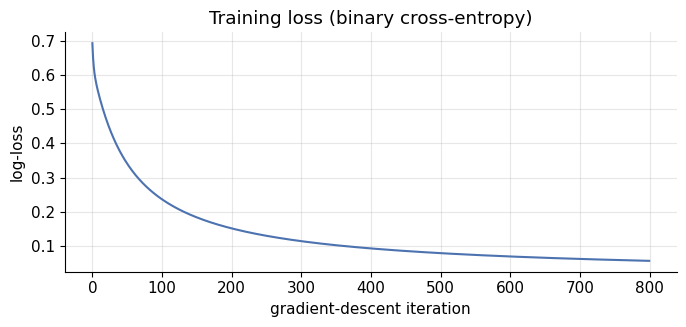

final training log-loss: 0.0569


In [11]:
def sigmoid(z):
    '''Numerically stable logistic sigmoid.'''
    z = np.asarray(z, float)
    out = np.empty_like(z)
    pos, neg = z >= 0, z < 0
    out[pos] = 1 / (1 + np.exp(-z[pos]))
    ez = np.exp(z[neg]); out[neg] = ez / (1 + ez)
    return out

class LogisticRegression:
    '''Binary logistic regression trained by batch gradient descent.'''
    def __init__(self, lr=1.0, n_iter=800, l2=1e-4):
        self.lr, self.n_iter, self.l2 = lr, n_iter, l2

    def fit(self, X, y):
        X, y = np.asarray(X, float), np.asarray(y, float)
        n, d = X.shape
        self.w_, self.b_, self.loss_ = np.zeros(d), 0.0, []
        eps = 1e-12
        for _ in range(self.n_iter):
            p = sigmoid(X @ self.w_ + self.b_)
            err = p - y
            self.w_ -= self.lr * (X.T @ err / n + self.l2 * self.w_)
            self.b_ -= self.lr * err.mean()
            self.loss_.append(float(-np.mean(y*np.log(p+eps) + (1-y)*np.log(1-p+eps))))
        return self

    def predict_proba(self, X): return sigmoid(np.asarray(X, float) @ self.w_ + self.b_)
    def predict(self, X, thr=0.5): return (self.predict_proba(X) >= thr).astype(int)

from sklearn.model_selection import train_test_split
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=SEED, stratify=y)
clf = LogisticRegression().fit(Xtr, ytr)

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(clf.loss_, color="#4C72B0"); ax.set_title("Training loss (binary cross-entropy)")
ax.set_xlabel("gradient-descent iteration"); ax.set_ylabel("log-loss")
plt.tight_layout(); plt.show()
print("final training log-loss:", round(clf.loss_[-1], 4))

## 3. Evaluation: confusion matrix, precision/recall, ROC and AUC

Accuracy alone hides *how* a classifier is wrong, so we build the confusion matrix and derive precision, recall and F1 from it:

$$
\text{precision} = \frac{TP}{TP + FP}, \quad
\text{recall} = \frac{TP}{TP + FN}, \quad
F_1 = \frac{2\,\text{precision}\cdot\text{recall}}{\text{precision} + \text{recall}}.
$$

To judge the classifier across all thresholds we trace the ROC curve (true-positive rate vs false-positive rate) and report its area under the curve (AUC) - 1.0 is perfect, 0.5 is coin-flip.

In [ ]:
def confusion_matrix(y_true, y_pred):
    cm = np.zeros((2, 2), int)
    for t, p in zip(np.asarray(y_true, int), np.asarray(y_pred, int)):
        cm[t, p] += 1
    return cm

def prf(cm):
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2*precision*recall/(precision+recall) if precision+recall else 0.0
    return precision, recall, f1

def roc_curve(y_true, scores):
    y_true = np.asarray(y_true, int); scores = np.asarray(scores, float)
    order = np.argsort(-scores)
    ys = y_true[order]
    P, Nn = max(int(y_true.sum()), 1), max(int((1 - y_true).sum()), 1)
    tpr = np.concatenate([[0], np.cumsum(ys) / P])
    fpr = np.concatenate([[0], np.cumsum(1 - ys) / Nn])
    return fpr, tpr

def auc(fpr, tpr): return float(np.trapezoid(tpr, fpr))

ypred = clf.predict(Xte)
proba = clf.predict_proba(Xte)
cm = confusion_matrix(yte, ypred)
precision, recall, f1 = prf(cm)
fpr, tpr = roc_curve(yte, proba)
acc = float(np.mean(ypred == yte))
print(f"accuracy={acc:.3f}  precision={precision:.3f}  recall={recall:.3f}  "
      f"F1={f1:.3f}  AUC={auc(fpr, tpr):.3f}")

# validate
from sklearn.linear_model import LogisticRegression as SkLogReg
sk = SkLogReg(max_iter=1000).fit(Xtr, ytr)
print(f"scikit-learn accuracy={sk.score(Xte, yte):.3f}  (ours={acc:.3f})")

accuracy=1.000  precision=1.000  recall=1.000  F1=1.000  AUC=1.000
scikit-learn accuracy=1.000  (ours=1.000)


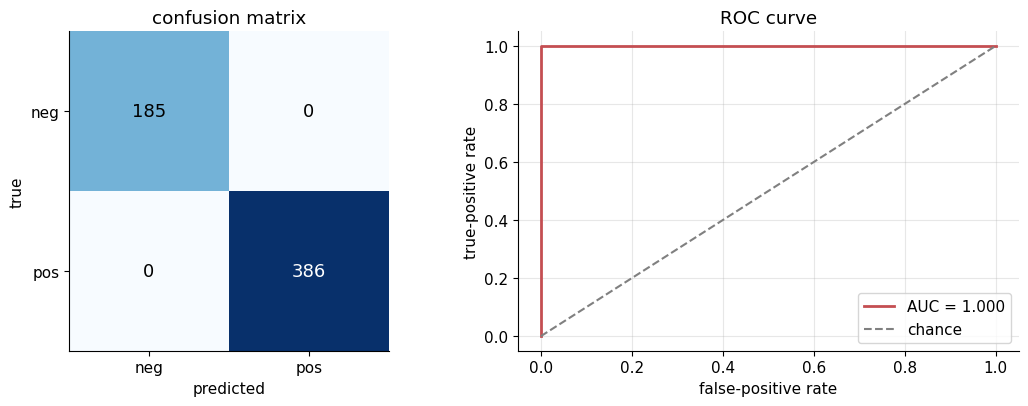

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
# confusion matrix heatmap
ax[0].imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax[0].text(j, i, cm[i, j], ha="center", va="center",
                   color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=13)
ax[0].set_xticks([0, 1], ["neg", "pos"]); ax[0].set_yticks([0, 1], ["neg", "pos"])
ax[0].set_xlabel("predicted"); ax[0].set_ylabel("true"); ax[0].set_title("confusion matrix")
ax[0].grid(False)
# ROC curve
ax[1].plot(fpr, tpr, color="#C44E52", linewidth=2, label=f"AUC = {auc(fpr, tpr):.3f}")
ax[1].plot([0, 1], [0, 1], "--", color="gray", label="chance")
ax[1].set_xlabel("false-positive rate"); ax[1].set_ylabel("true-positive rate")
ax[1].set_title("ROC curve"); ax[1].legend(loc="lower right")
plt.tight_layout(); plt.show()

## 4. What did the model learn?

Because logistic regression is linear, each vocabulary word has a single weight $w_j$. The most positive and most negative weights tell us which words drive the prediction - a quick, honest interpretability check.

In [14]:
weights = sorted(((clf.w_[j], vocab_inv[j]) for j in range(len(clf.w_))), reverse=True)
print("Top POSITIVE words:        Top NEGATIVE words:")
for (wp, tp), (wn, tn) in zip(weights[:8], weights[::-1][:8]):
    print(f"  {tp:14s} {wp:+.2f}     {tn:14s} {wn:+.2f}")

Top POSITIVE words:        Top NEGATIVE words:
  stunning       +2.76     buy            -5.42
  expectations   +2.75     itchy          -2.91
  exceeded       +2.75     honestly       -2.85
  absolutely     +2.75     looks          -2.85
  true           +2.67     flimsy         -2.85
  feels          +2.67     overpriced     -2.70
  beautiful      +2.66     cheap          -2.68
  flattering     +2.54     shapeless      -2.63


## 5. Sentiment per style - feeding the synthesis

Finally we score every binary review with the trained model and average the predicted positive-probability within each style.

saved results to sentiment_by_style.csv


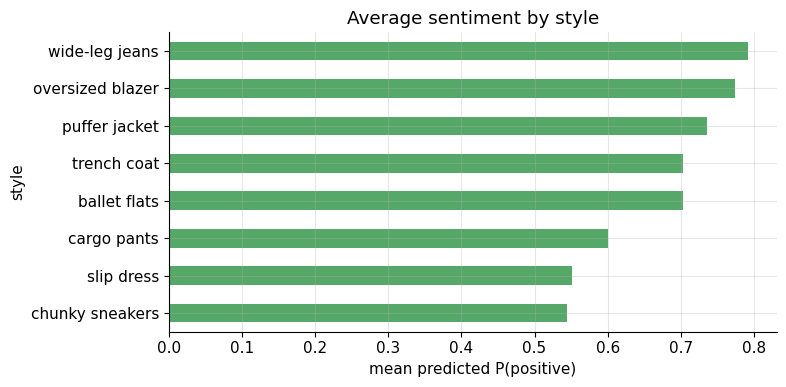

,style,mean_sentiment,mean_rating,n_reviews
0,wide-leg jeans,0.792,3.907,291
1,oversized blazer,0.774,3.864,287
2,puffer jacket,0.736,3.759,278
3,trench coat,0.703,3.552,288
4,ballet flats,0.702,3.607,285
5,cargo pants,0.600,3.287,286
6,slip dress,0.551,3.178,286
7,chunky sneakers,0.545,3.081,283


In [16]:
binary = binary.copy()
binary["pred_proba"] = clf.predict_proba(X)
sentiment_by_style = (binary.groupby("style")
                      .agg(mean_sentiment=("pred_proba", "mean"),
                           mean_rating=("rating", "mean"),
                           n_reviews=("pred_proba", "size"))
                      .sort_values("mean_sentiment", ascending=False).reset_index())
sentiment_by_style.to_csv(RESULTS / "sentiment_by_style.csv", index=False)
print("saved results to sentiment_by_style.csv")

ax = sentiment_by_style.plot.barh(x="style", y="mean_sentiment", legend=False,
                                  color="#55A868", figsize=(8, 4))
ax.set_xlabel("mean predicted P(positive)"); ax.set_title("Average sentiment by style")
ax.invert_yaxis(); plt.tight_layout(); plt.show()
sentiment_by_style.round(3)

In [17]:
assert X.shape[0] == len(binary) and X.shape[1] == len(vec.vocabulary_)
assert np.allclose(np.linalg.norm(X[X.sum(axis=1) > 0], axis=1), 1.0, atol=1e-6), "rows not L2-normalised"
assert auc(fpr, tpr) > 0.85, "AUC unexpectedly low"
assert cm.sum() == len(yte)
print("all sanity checks")

all sanity checks


## 6. Calibration and the decision threshold

A near-perfect AUC says the ranking is excellent, but two practical questions remain. Calibration: when the model says "0.8 positive", are about 80% of such reviews actually positive? A reliability diagram bins predictions by predicted probability and plots the observed positive rate against it — the diagonal is perfect calibration. The threshold: 0.5 is only a default; sweeping it shows how precision, recall and F1 trade off, and how wide the band of thresholds that keeps the classifier near-perfect really is.

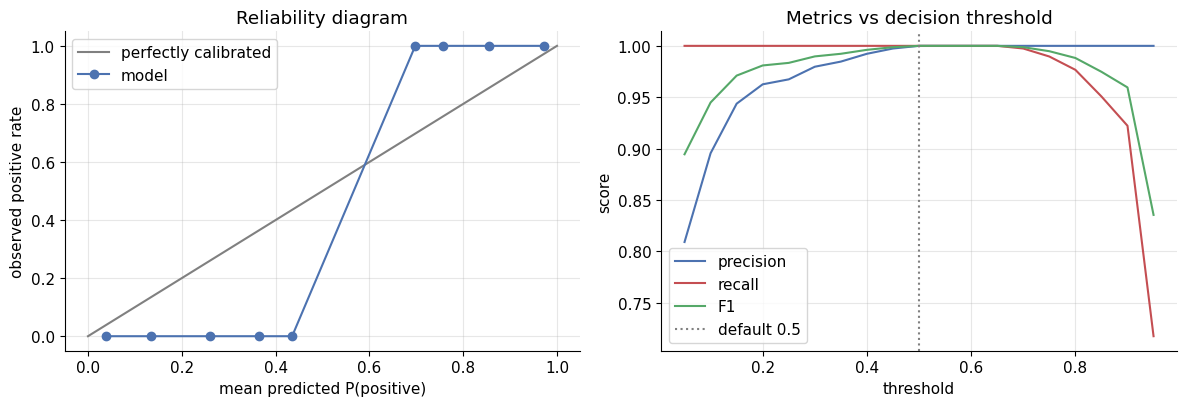

F1 is maximised at threshold ~ 0.50 (F1 = 1.000)


In [23]:
# Reliability diagram + precision/recall/F1 across decision thresholds, on the held-out set.
def reliability(y_true, scores, n_bins=10):
    edges = np.linspace(0, 1, n_bins + 1)
    mids, freqs = [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (scores >= lo) & ((scores < hi) | ((hi == 1.0) & (scores <= hi)))
        if m.any():
            mids.append(scores[m].mean()); freqs.append(y_true[m].mean())
    return np.array(mids), np.array(freqs)

mids, freqs = reliability(yte, proba)

thresholds = np.linspace(0.05, 0.95, 19)
prec, rec, f1s = [], [], []
for thr in thresholds:
    p, r, f = prf(confusion_matrix(yte, (proba >= thr).astype(int)))
    prec.append(p); rec.append(r); f1s.append(f)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].plot([0, 1], [0, 1], "-", color="gray", label="perfectly calibrated")
ax[0].plot(mids, freqs, "o-", color="#4C72B0", label="model")
ax[0].set_title("Reliability diagram"); ax[0].set_xlabel("mean predicted P(positive)")
ax[0].set_ylabel("observed positive rate"); ax[0].legend()
ax[1].plot(thresholds, prec, label="precision", color="#4C72B0")
ax[1].plot(thresholds, rec, label="recall", color="#C44E52")
ax[1].plot(thresholds, f1s, label="F1", color="#55A868")
ax[1].axvline(0.5, ls=":", color="gray", label="default 0.5")
ax[1].set_title("Metrics vs decision threshold"); ax[1].set_xlabel("threshold")
ax[1].set_ylabel("score"); ax[1].legend()
plt.tight_layout(); plt.show()

best_thr = thresholds[int(np.argmax(f1s))]
print(f"F1 is maximised at threshold ~ {best_thr:.2f} (F1 = {max(f1s):.3f})")

Because the two classes are almost linearly separable here, a wide band of thresholds keeps F1 at its ceiling - the model has a comfortable operating margin rather than balancing on a knife-edge. And with the reliability curve hugging the diagonal, the probabilities are trustworthy as numbers, not just as a ranking - we have to average them per style instead of only thresholding them.